<a href="https://colab.research.google.com/github/The-Professor99/ML_Practice/blob/main/hands_on_learning/hands_on_ml_with_scikit-learn_Aurelien_textbook/Chap_14_Deep_Computer_Vision_using_CNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import load_sample_image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

In [ ]:
china = load_sample_image('china.jpg') / 255
flower = load_sample_image("flower.jpg") / 255

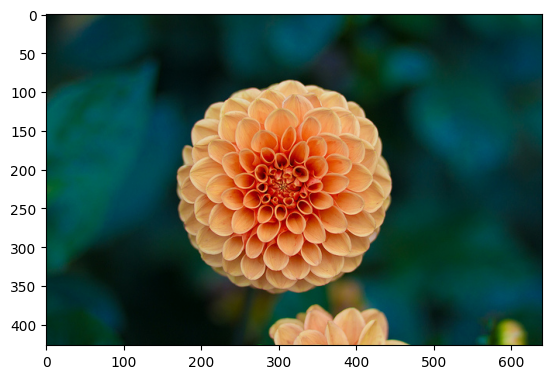

In [ ]:
plt.imshow(flower)

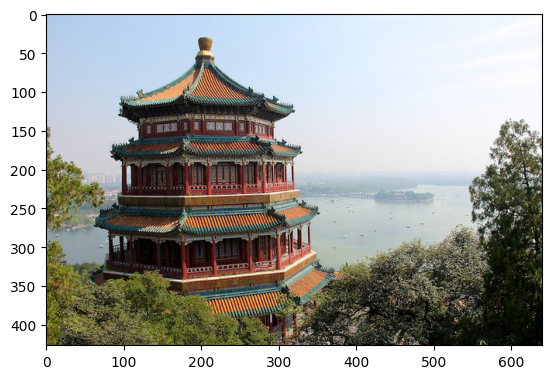

In [ ]:
plt.imshow(china)

In [ ]:
images = np.array([china, flower])
batch_size, height, width, channels = images.shape

In [ ]:
batch_size, height, width,channels

(2, 427, 640, 3)

In [ ]:
# create 2 filters
filters = np.zeros(shape=(7, 7, channels, 2), dtype=np.float32)
filters[:, 3, :, 0] = 1 # vertical line
filters[3, :, :, 1] = 1 # horizontal line
# why does filter have (7, 7, channels, 2) shape though?

In [ ]:
filters

array([[[[0., 0.],
         [0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.],
         [0., 0.]],

        [[1., 0.],
         [1., 0.],
         [1., 0.]],

        [[0., 0.],
         [0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.],
         [0., 0.]]],


       [[[0., 0.],
         [0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.],
         [0., 0.]],

        [[1., 0.],
         [1., 0.],
         [1., 0.]],

        [[0., 0.],
         [0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.],
         [0., 0.]]],


       [[[0., 0.],
         [0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.],
         [0., 0.]],

        [[0., 0.],
         [0., 0.],
         [0., 

In [ ]:
outputs = tf.nn.conv2d(images, filters, strides=1,
                       padding="SAME")

In [ ]:
outputs[0, :, :, 1]

<tf.Tensor: shape=(427, 640), dtype=float64, numpy=
array([[ 9.50588235, 11.88235294, 14.25882353, ..., 17.74901961,
        14.80392157, 11.84705882],
       [ 9.45882353, 11.83529412, 14.21176471, ..., 17.8       ,
        14.84705882, 11.88235294],
       [ 9.50588235, 11.88235294, 14.25882353, ..., 17.86666667,
        14.89411765, 11.92156863],
       ...,
       [ 4.04313725,  4.8627451 ,  5.4745098 , ...,  1.74117647,
         1.72941176,  1.24313725],
       [ 3.93333333,  4.51764706,  5.28235294, ...,  0.46666667,
         0.45490196,  0.44705882],
       [ 3.41176471,  4.36078431,  5.30588235, ...,  0.96862745,
         0.96862745,  0.95294118]])>

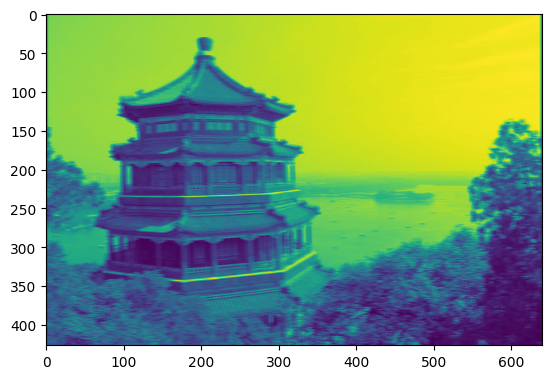

In [ ]:
plt.imshow(outputs[0, :, :, 1])

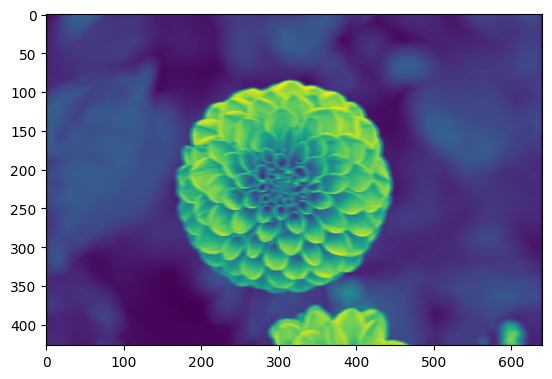

In [ ]:
plt.imshow(outputs[1, :, :, 1])

In [ ]:
conv = keras.layers.Conv2D(filters=32, kernel_size=3,
                           strides=1, padding="same",
                          activation="relu")

In [ ]:
max_pool = keras.layers.MaxPool2D(pool_size=2)

In [ ]:
# simple CNN to tackle the Fashion mnist dataset
model = keras.models.Sequential([
    keras.layers.Conv2D(64, 7, activation="relu",
                       padding="same",
                       input_shape=[28, 28, 1]),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(128, 3, activation="relu",
                       padding="same"),
    keras.layers.Conv2D(128, 3, activation="relu",
                       padding="same"),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(256, 3, activation="relu",
                       padding="same"),
    keras.layers.Conv2D(256, 3, activation="relu",
                       padding="same"),
    keras.layers.MaxPooling2D(2),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation="softmax")
])

### Using Pretrained Models

In [ ]:
images_resized = tf.image.resize(images, [224, 224])

In [ ]:
images_resized

<tf.Tensor: shape=(2, 224, 224, 3), dtype=float32, numpy=
array([[[[6.80449069e-01, 7.86331415e-01, 9.03978467e-01],
         [6.82352960e-01, 7.88235307e-01, 9.05882359e-01],
         [6.85272276e-01, 7.91154623e-01, 9.08801675e-01],
         ...,
         [9.70404387e-01, 9.74325955e-01, 9.93933797e-01],
         [9.78247523e-01, 9.82169092e-01, 9.99540448e-01],
         [9.82169092e-01, 9.86090660e-01, 1.00000000e+00]],

        [[6.83762252e-01, 7.89644599e-01, 9.07291651e-01],
         [6.82654977e-01, 7.88537323e-01, 9.06184375e-01],
         [6.84865236e-01, 7.90747583e-01, 9.08394635e-01],
         ...,
         [9.81801450e-01, 9.85723019e-01, 9.98590708e-01],
         [9.86261427e-01, 9.90182996e-01, 1.00000000e+00],
         [9.88235295e-01, 9.92156863e-01, 1.00000000e+00]],

        [[6.83394611e-01, 7.87193656e-01, 9.01960790e-01],
         [6.87316179e-01, 7.91115224e-01, 9.05882359e-01],
         [6.90209270e-01, 7.94008255e-01, 9.08775389e-01],
         ...,
         [9

In [ ]:
inputs = keras.applications.resnet50.preprocess_input(images_resized * 255)

In [ ]:
model = keras.applications.resnet50.ResNet50(weights="imagenet")

102967424/102967424 [==============================] - 350s 3us/step


In [ ]:
Y_proba = model.predict(inputs)

1/1 [==============================] - 3s 3s/step


In [ ]:
top_K = keras.applications.resnet50.decode_predictions(Y_proba, top=5)
for image_index in range(len(images)):
    print("Image #{}".format(image_index))
    for class_id, name, y_proba in top_K[image_index]:
        print(" {} - {:12s} {:.2f}%".format(class_id, name, y_proba * 100))
    print()

Image #0
 n02825657 - bell_cote    82.35%
 n03877845 - palace       6.75%
 n03781244 - monastery    4.19%
 n02980441 - castle       3.16%
 n03028079 - church       1.00%
 n02843684 - birdhouse    0.66%
 n04435653 - tile_roof    0.38%
 n04346328 - stupa        0.37%
 n02859443 - boathouse    0.24%
 n09332890 - lakeside     0.23%

Image #1
 n03530642 - honeycomb    49.81%
 n13040303 - stinkhorn    33.96%
 n02206856 - bee          4.35%
 n11939491 - daisy        3.23%
 n12985857 - coral_fungus 2.66%
 n04522168 - vase         2.01%
 n01950731 - sea_slug     0.64%
 n13052670 - hen-of-the-woods 0.33%
 n13133613 - ear          0.29%
 n13044778 - earthstar    0.21%



### Pretrained Models for Transfer Learning

In [ ]:
import tensorflow_datasets as tfds

In [ ]:
dataset, info = tfds.load("tf_flowers", as_supervised=True, with_info=True)
dataset_size = info.splits["train"].num_examples
class_names = info.features["label"].names
n_classes = info.features["label"].num_classes

In [ ]:
test_set, valid_set, train_set = tfds.load("tf_flowers", split=['train[:10%]', 'train[10%:25%]', 'train[25%:]'])

In [ ]:
test_set

<_PrefetchDataset element_spec={'image': TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None)}>

In [ ]:
valid_set

<_PrefetchDataset element_spec={'image': TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None)}>

In [ ]:
train_set

<_PrefetchDataset element_spec={'image': TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None)}>

In [ ]:
def preprocess(input_):
    image = input_["image"]
    label = input_["label"]
    resized_image = tf.image.resize(image, [224, 224])
    final_image = keras.applications.xception.preprocess_input(resized_image)
    return final_image, label

In [ ]:
batch_size = 32
train_set = train_set.shuffle(1000)
train_set = train_set.map(preprocess).batch(batch_size).prefetch(1)
valid_set = valid_set.map(preprocess).batch(batch_size).prefetch(1)
test_set = test_set.map(preprocess).batch(batch_size).prefetch(1)

Tensor("args_0:0", shape=(None, None, 3), dtype=uint8)
===
Tensor("args_1:0", shape=(), dtype=int64)
Tensor("args_0:0", shape=(None, None, 3), dtype=uint8)
===
Tensor("args_1:0", shape=(), dtype=int64)
Tensor("args_0:0", shape=(None, None, 3), dtype=uint8)
===
Tensor("args_1:0", shape=(), dtype=int64)


In [ ]:
base_model = keras.applications.xception.Xception(
    weights="imagenet",
    include_top=False)
avg = keras.layers.GlobalAveragePooling2D()(base_model.output)
output = keras.layers.Dense(n_classes, activation="softmax")(avg)
model = keras.Model(inputs=base_model.input, outputs=output)

In [ ]:
for layer in base_model.layers:
    layer.trainable = False

In [ ]:
optimizer = keras.optimizers.SGD(learning_rate=0.2, momentum=0.9)
model.compile(loss="sparse_categorical_crossentropy",
             optimizer=optimizer, metrics=["accuracy"])
history = model.fit(train_set, epochs=5, validation_data=valid_set)

Epoch 1/5
86/86 [==============================] - 369s 4s/step - loss: 2.0475 - accuracy: 0.7794 - val_loss: 1.6294 - val_accuracy: 0.8367
Epoch 2/5
86/86 [==============================] - 350s 4s/step - loss: 0.7396 - accuracy: 0.8968 - val_loss: 1.7113 - val_accuracy: 0.8439
Epoch 3/5
86/86 [==============================] - 562s 7s/step - loss: 0.4541 - accuracy: 0.9251 - val_loss: 1.6119 - val_accuracy: 0.8385
Epoch 4/5
86/86 [==============================] - 405s 5s/step - loss: 0.2776 - accuracy: 0.9451 - val_loss: 1.2398 - val_accuracy: 0.8657
Epoch 5/5
86/86 [==============================] - 409s 5s/step - loss: 0.3014 - accuracy: 0.9400 - val_loss: 1.8415 - val_accuracy: 0.8185


In [ ]:
for layer in base_model.layers:
    layer.trainable = True

optimizer = keras.optimizers.SGD(learning_rate=0.01,
                                momentum=0.9)
model.compile(...)
history = model.fit(...)

### Classification and Localization

In [ ]:
base_model = keras.applications.xception.Xception(weights="imagenet",
                                                 include_top=False)
avg = keras.layers.GlobalAveragePooling2D()(base_model.output)
class_output = keras.layers.Dense(n_classes,
                                  activation="softmax")(avg)
loc_output = keras.layers.Dense(4)(avg)
model = keras.Model(inputs=base_model.input,
                    outputs=[class_output, loc_output])
model.compile(loss=["sparse_categorical_crossentropy", "mse"],
             loss_weights=[0.8, 0.2],
             optimizer=optimizer, metrics=["accuracy"])